#  <span style='color:blue'> Mini Project: COVID-19 Detection from Chest X-rays using CNN
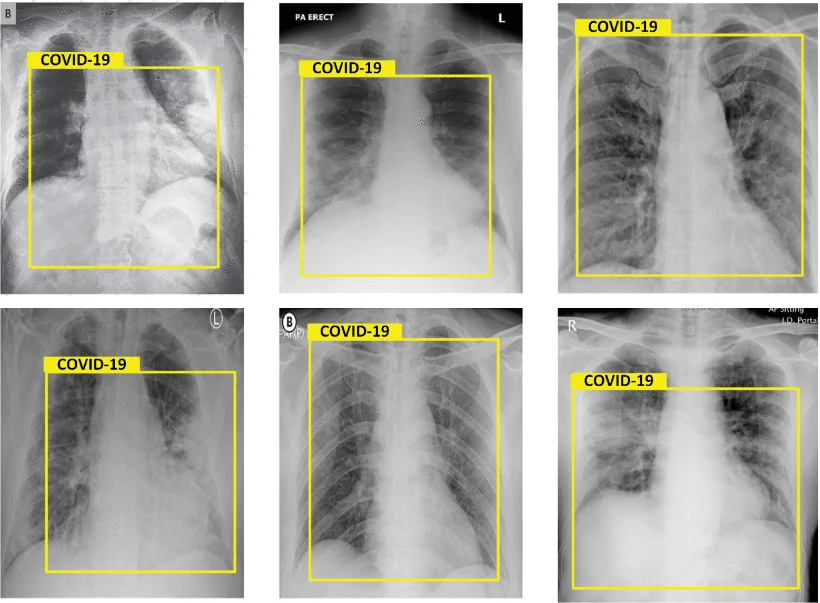

#  <span style='color:blue'> Author: Madhusudan Manna-IIT Guwahati,AI,ML,DS-BATCH-13

## <span style='color: violet'> Objective
A healthcare startup aims to accelerate and improve COVID-19 diagnosis using deep learning technologies. The current testing procedures are time-consuming and rely heavily on manual radiological examination, which limits scalability in pandemic situations.
As a data scientist, your task is to build a Convolutional Neural Network (CNN) model that can automatically detect COVID-19 from chest X-ray images. This solution can help hospitals:
•	Reduce diagnosis time.
•	Minimize burden on radiologists.
•	Scale testing across regions with limited radiological expertise.
This project allows you to apply deep learning concepts, understand how CNNs process image data, and build real-world applications that can assist the medical community.


## <span style='color: violet'>Dataset
You will use the dataset provided in the following Kaggle project:
https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset
The dataset contains:
•	COVID-19 chest X-ray images
•	Normal (no disease) chest X-ray images
•	Viral Pneumonia chest X-ray images


## <span style='color: violet'>Data Dictionary
Each image is labelled into one of the following classes:
•	COVID-19 – Confirmed COVID infection.
•	Viral Pneumonia – Non-COVID lung infection.
•	Normal – No visible lung abnormality.


## <span style='color: indigo'>Task 1: Data Loading and Exploration

In [1]:
# ─── Import necessary libraries ───
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.21.0
All libraries imported successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.21.0
All libraries imported successfully!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install opencv-python
import os
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [4]:
# Load Dataset Paths
train_path = 'Covid19-dataset/train'
test_path = 'Covid19-dataset/test'

# Check folders
import os

print("Train folders:", os.listdir(train_path))
print("Test folders:", os.listdir(test_path))

Train folders: ['Covid', 'Normal', 'Viral Pneumonia']
Test folders: ['Covid', 'Normal', 'Viral Pneumonia']


In [3]:
import os
import pandas as pd

train_path = 'Covid19-dataset/train'

data = []

# Read image paths and labels
for label in os.listdir(train_path):
    folder_path = os.path.join(train_path, label)

    if os.path.isdir(folder_path):
        for img in os.listdir(folder_path):
            data.append([os.path.join(folder_path, img), label])

# Create DataFrame
df = pd.DataFrame(data, columns=['image_path', 'label'])

# Show first 10 rows
df.head(10)


,image_path,label
0,Covid19-dataset/train\Covid\01.jpeg,Covid
1,Covid19-dataset/train\Covid\010.png,Covid
2,Covid19-dataset/train\Covid\012.jpeg,Covid
3,Covid19-dataset/train\Covid\015.jpg,Covid
4,Covid19-dataset/train\Covid\019.png,Covid
5,Covid19-dataset/train\Covid\02.jpeg,Covid
6,Covid19-dataset/train\Covid\020.jpg,Covid
7,Covid19-dataset/train\Covid\021.jpeg,Covid
8,Covid19-dataset/train\Covid\022.jpeg,Covid
9,Covid19-dataset/train\Covid\024.jpeg,Covid


In [6]:
#Data Preprocessing-
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [7]:
#Build CNN Model-

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

In [8]:
#Compile the Model-
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
#Train the Model-
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 755ms/step - accuracy: 0.4502 - loss: 1.0817 - val_accuracy: 0.6970 - val_loss: 0.9812
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 578ms/step - accuracy: 0.6096 - loss: 0.9253 - val_accuracy: 0.7121 - val_loss: 0.6637
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 578ms/step - accuracy: 0.6932 - loss: 0.6965 - val_accuracy: 0.7121 - val_loss: 0.4950
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 595ms/step - accuracy: 0.7570 - loss: 0.6406 - val_accuracy: 0.8636 - val_loss: 0.4346
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 562ms/step - accuracy: 0.8088 - loss: 0.4629 - val_accuracy: 0.7424 - val_loss: 0.4195
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 601ms/step - accuracy: 0.8127 - loss: 0.5220 - val_accuracy: 0.6970 - val_loss: 0.5167
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 588ms/step - accuracy: 0.8207 - loss: 0.4820 - val_accuracy: 0.7576 - val_loss: 0.4049
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 591ms/step - accuracy: 0.8406 - loss: 0.4189 - val_accuracy: 0.6970 - val_loss:

In [10]:
#Evaluate the Model-
loss, accuracy = model.evaluate(test_data)

print('Test Loss :', loss)
print('Test Accuracy :', accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.7576 - loss: 0.4362
Test Loss : 0.4362325966358185
Test Accuracy : 0.7575757503509521


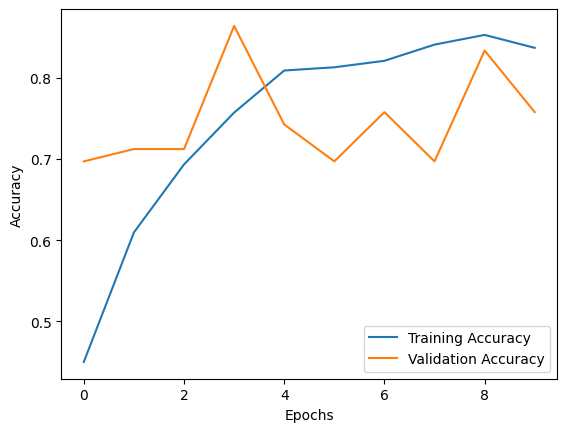

In [11]:
#Plot Accuracy Graph-
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

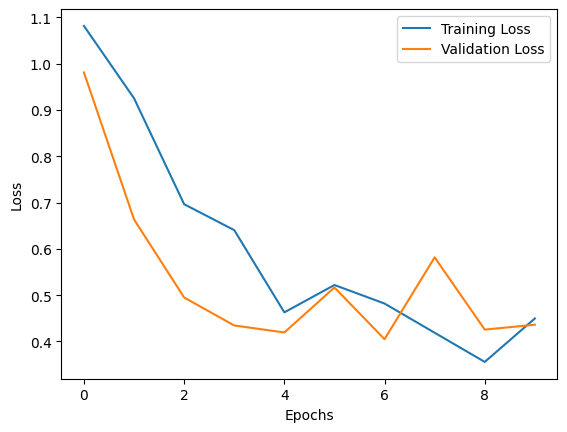

In [12]:
#Plot Loss Graph-
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [4]:
#Predict New Image-

img_path = r"C:\Users\USER\OneDrive\E&ICT,IIT,Guwahati,AI,ML,DS\Mini Project & Capstone Project\8.Image classification using CNN\Covid19-dataset\test\Covid\094.png"

df.head()

,image_path,label
0,Covid19-dataset/train\Covid\01.jpeg,Covid
1,Covid19-dataset/train\Covid\010.png,Covid
2,Covid19-dataset/train\Covid\012.jpeg,Covid
3,Covid19-dataset/train\Covid\015.jpg,Covid
4,Covid19-dataset/train\Covid\019.png,Covid


In [16]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load image with correct size
img = image.load_img(img_path, target_size=(128,128))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

print(prediction)

# Predicted class
predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[[0.9166492  0.07957177 0.00377895]]
Predicted Class: 0


In [17]:
#Save the Model-

model.save('covid19_cnn_model.h5')

In [18]:
# ─── Load images from different folders and label them ───
IMG_SIZE = 128  # Resize to 128x128
CLASSES = ['Covid', 'Normal', 'Viral Pneumonia']
BASE_DIR = 'Covid19-dataset/train'

images = []
labels = []

for label, cls in enumerate(CLASSES):
    folder = os.path.join(BASE_DIR, cls)
    for img_file in os.listdir(folder):
        img_path = os.path.join(folder, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(cls)

images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded: {len(images)}")
print(f"Image shape: {images[0].shape}")

Total images loaded: 251
Image shape: (128, 128, 3)


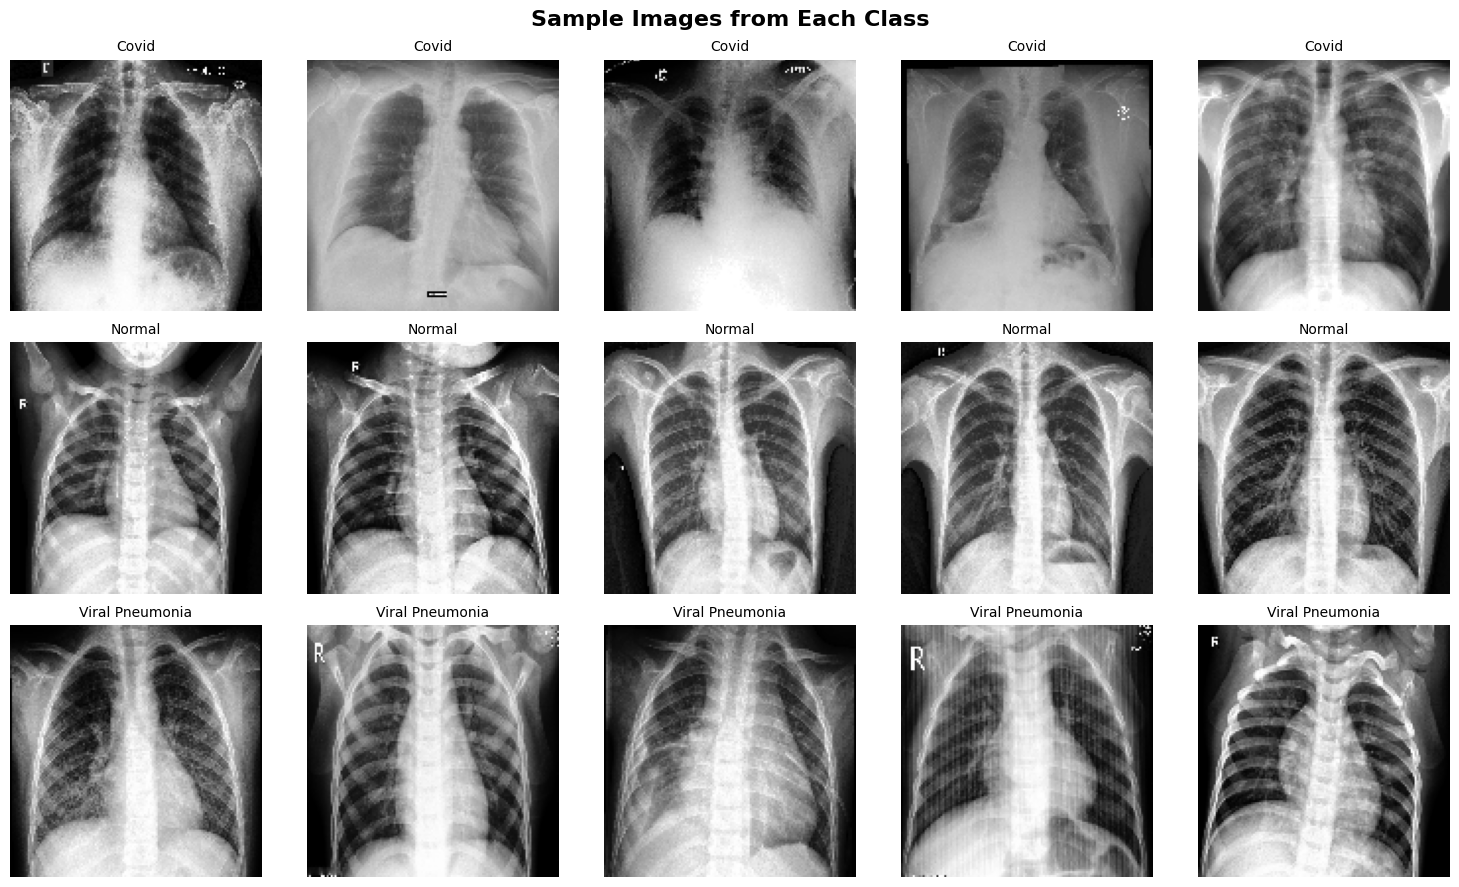

In [19]:
# ─── Display a few sample images from each class ───
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASSES):
    cls_imgs = images[labels == cls][:5]
    for col in range(5):
        axes[row, col].imshow(cls_imgs[col])
        axes[row, col].set_title(cls, fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# ─── Print dataset size per class ───
for cls in CLASSES:
    count = np.sum(labels == cls)
    print(f"  {cls}: {count} images")

print(f"\nTotal: {len(labels)} images")

  Covid: 111 images
  Normal: 70 images
  Viral Pneumonia: 70 images

Total: 251 images


## <span style='color: indigo'>Task 2: Data Preprocessing

In [21]:
# Imports
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Normalize pixel values
X = images.astype('float32') / 255.0

print(f"Pixel range after normalization: [{X.min():.2f}, {X.max():.2f}]")

# Encode labels
le = LabelEncoder()

# Integer encoding
y_encoded = le.fit_transform(labels)

# One-hot encoding
y_onehot = to_categorical(y_encoded, num_classes=3)

# Display mapping
print("\nLabel mapping:")

for i, cls in enumerate(le.classes_):
    print(f"{cls} → {i}")

print(f"\ny_encoded shape : {y_encoded.shape}")
print(f"y_onehot shape : {y_onehot.shape}")

Pixel range after normalization: [0.00, 1.00]

Label mapping:
Covid → 0
Normal → 1
Viral Pneumonia → 2

y_encoded shape : (251,)
y_onehot shape : (251, 3)


In [22]:
# Import
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_onehot,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Split training data into train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42
)

# Print shapes
print(f"Training   : {X_train.shape[0]} samples")
print(f"Validation : {X_val.shape[0]} samples")
print(f"Test       : {X_test.shape[0]} samples")

Training   : 180 samples
Validation : 20 samples
Test       : 51 samples


## <span style='color: indigo'> Task 3: Exploratory Data Analysis (EDA)

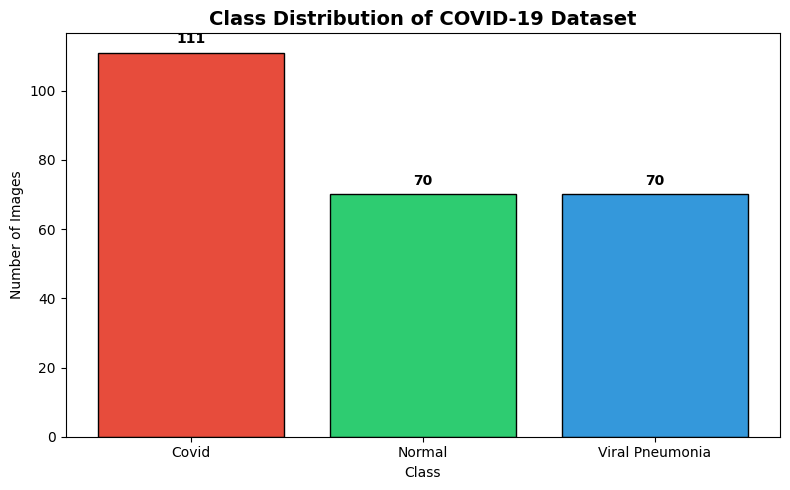

Class distribution:
  Covid: 111
  Normal: 70
  Viral Pneumonia: 70


In [23]:
# ─── Visualize class distribution using bar plots ───
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(8, 5))
bars = plt.bar(unique, counts, color=['#E74C3C', '#2ECC71', '#3498DB'], edgecolor='black')
plt.title('Class Distribution of COVID-19 Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("Class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"  {cls}: {cnt}")

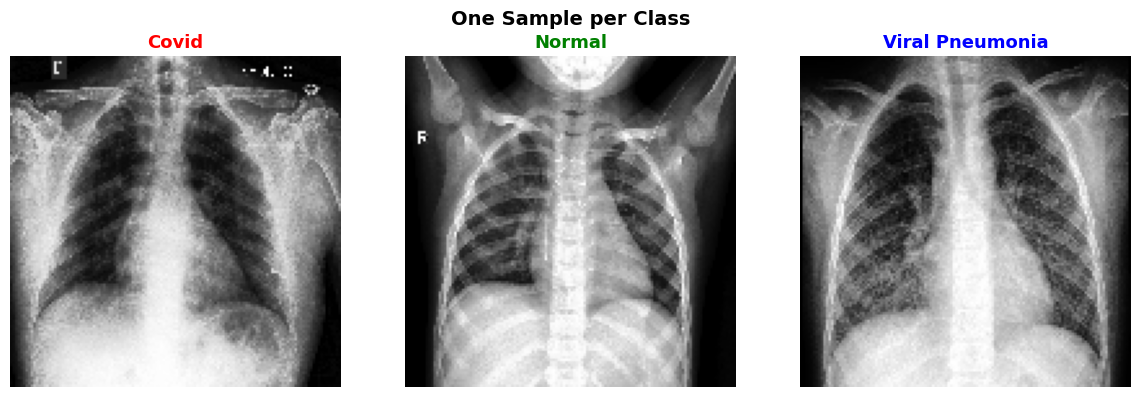

In [24]:
# ─── Plot sample images with class names ───
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('One Sample per Class', fontsize=14, fontweight='bold')

colors = ['red', 'green', 'blue']
for ax, cls, color in zip(axes, CLASSES, colors):
    idx = np.where(labels == cls)[0][0]
    ax.imshow(images[idx])
    ax.set_title(cls, color=color, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

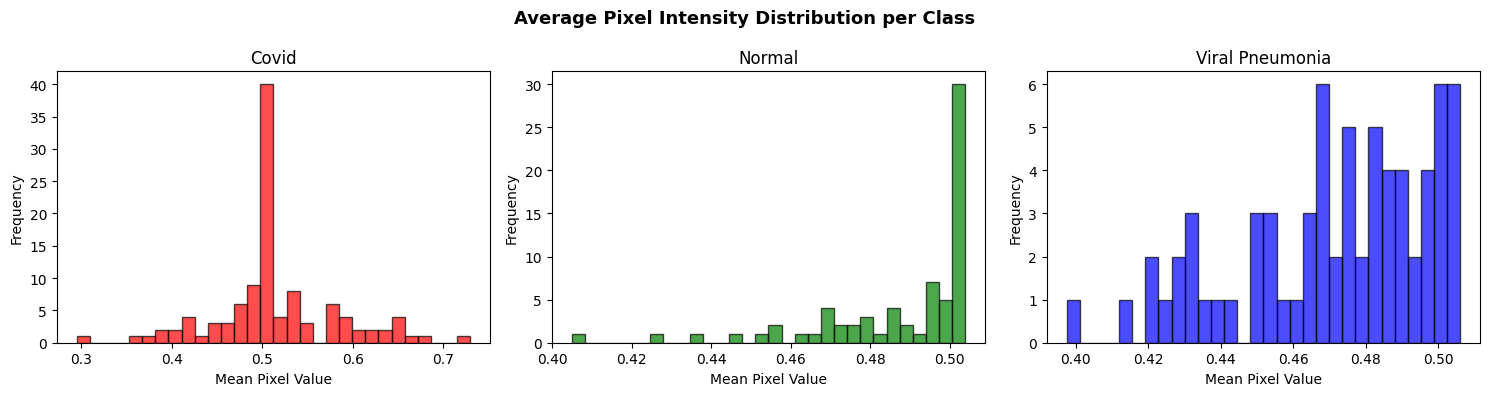

In [25]:
# ─── Pixel intensity distribution per class ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Average Pixel Intensity Distribution per Class', fontsize=13, fontweight='bold')

for ax, cls, color in zip(axes, CLASSES, ['red', 'green', 'blue']):
    cls_imgs = (images[labels == cls].astype(float) / 255.0).mean(axis=(1,2,3))
    ax.hist(cls_imgs, bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(cls)
    ax.set_xlabel('Mean Pixel Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## <span style='color: indigo'> Task 4: CNN Model Building

In [ ]:
# ─────────────────────────────────────────
# Import Required Libraries
# ─────────────────────────────────────────
import tensorflow as tf

from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# ─────────────────────────────────────────
# Build Basic CNN Model
# ─────────────────────────────────────────
def build_basic_cnn(input_shape=(128, 128, 3), num_classes=3):

    model = Sequential([

        # First Convolution Block
        Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            input_shape=input_shape
        ),
        MaxPooling2D((2,2)),

        # Second Convolution Block
        Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same'
        ),
        MaxPooling2D((2,2)),

        # Third Convolution Block
        Conv2D(
            128,
            (3,3),
            activation='relu',
            padding='same'
        ),
        MaxPooling2D((2,2)),

        # Flatten Layer
        Flatten(),

        # Fully Connected Layer
        Dense(256, activation='relu'),

        # Dropout for Overfitting Prevention
        Dropout(0.5),

        # Output Layer
        Dense(num_classes, activation='softmax')

    ], name='Basic_CNN')

    return model

# ─────────────────────────────────────────
# Create Model
# ─────────────────────────────────────────
model_cnn = build_basic_cnn()

# ─────────────────────────────────────────
# Compile Model
# ─────────────────────────────────────────
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ─────────────────────────────────────────
# Display Model Summary
# ─────────────────────────────────────────
model_cnn.summary()

Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,482,883 (32.36 MB)

 Trainable params: 8,482,883 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ─────────────────────────────────────────
# Import Required Callbacks
# ─────────────────────────────────────────
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# ─────────────────────────────────────────
# Define Callbacks
# ─────────────────────────────────────────
callbacks_basic = [

    # Stop training if validation loss does not improve
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ─────────────────────────────────────────
# Train Basic CNN Model
# ─────────────────────────────────────────
history_cnn = model_cnn.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=30,

    batch_size=32,

    callbacks=callbacks_basic,

    verbose=1
)

# ─────────────────────────────────────────
# Training Complete Message
# ─────────────────────────────────────────
print("Basic CNN training complete!")

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - accuracy: 0.4667 - loss: 1.3535 - val_accuracy: 0.5500 - val_loss: 0.9845 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.6611 - loss: 0.8657 - val_accuracy: 0.8500 - val_loss: 0.4156 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.7889 - loss: 0.4513 - val_accuracy: 0.9500 - val_loss: 0.1119 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.8944 - loss: 0.2421 - val_accuracy: 0.9500 - val_loss: 0.0816 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.9111 - loss: 0.2254 - val_accuracy: 0.9500 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.9278 - loss: 0.1753 - val_accuracy: 1.0000 - val_loss: 0.0426 - learning_rate: 0.0010
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.9500 - loss: 0.1193 - val_accuracy: 

In [ ]:
# ─────────────────────────────────────────
# Import Required Libraries
# ─────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import models, layers

# Import VGG16
from tensorflow.keras.applications import VGG16

# ─────────────────────────────────────────
# Build VGG16 Transfer Learning Model
# ─────────────────────────────────────────
def build_vgg16_transfer(
    input_shape=(128,128,3),
    num_classes=3
):

    # Load pretrained VGG16 model
    base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze all layers except last 4
    for layer in base.layers[:-4]:
        layer.trainable = False

    # Build final model
    model = models.Sequential([

        # Pretrained base model
        base,

        # Global pooling
        layers.GlobalAveragePooling2D(),

        # Fully connected layer
        layers.Dense(256, activation='relu'),

        # Dropout
        layers.Dropout(0.5),

        # Output layer
        layers.Dense(num_classes, activation='softmax')

    ], name='VGG16_Transfer')

    return model

# ─────────────────────────────────────────
# Create Model
# ─────────────────────────────────────────
model_vgg = build_vgg16_transfer()

# ─────────────────────────────────────────
# Compile Model
# ─────────────────────────────────────────
model_vgg.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# ─────────────────────────────────────────
# Display Model Summary
# ─────────────────────────────────────────
model_vgg.summary()

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 7,211,523 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
# Train VGG16 Transfer Learning
history_vgg = model_vgg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    callbacks=callbacks_basic,
    verbose=1
)
print("VGG16 Transfer Learning training complete!")

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 376ms/step - accuracy: 0.5778 - loss: 0.9088 - val_accuracy: 0.9500 - val_loss: 0.2598 - learning_rate: 1.0000e-04
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.7889 - loss: 0.5158 - val_accuracy: 1.0000 - val_loss: 0.1778 - learning_rate: 1.0000e-04
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8692 - loss: 0.3432
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 381ms/step - accuracy: 0.8778 - loss: 0.3207 - val_accuracy: 1.0000 - val_loss: 0.0607 - learning_rate: 1.0000e-04
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 360ms/step - accuracy: 0.9389 - loss: 0.1578 - val_accuracy: 1.0000 - val_loss: 0.0326 - learning_rate: 5.0000e-05
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - accuracy: 0.9722 - loss: 0.0794 - val_accuracy: 1.0000 - val_loss: 0.0354 - learning_rate: 5.0000e-05
Epoch 5: early stopping
Restoring model weights from the end of the b

In [ ]:
# ─────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50

# ─────────────────────────────────────────────────────────
# DATA AUGMENTATION
# ─────────────────────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fit augmentation on training data
datagen.fit(X_train)

# ─────────────────────────────────────────────────────────
# MODEL 3: RESNET50 TRANSFER LEARNING
# ─────────────────────────────────────────────────────────
def build_resnet50_transfer(input_shape=(128,128,3), num_classes=3):

    # Load pretrained ResNet50 model
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze most layers
    for layer in base.layers[:-10]:
        layer.trainable = False

    # Build model
    model = models.Sequential([
        base,

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),

        layers.BatchNormalization(),

        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ], name='ResNet50_Augmented')

    return model

# Create model
model_resnet = build_resnet50_transfer()

# Compile model
model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model_resnet.summary()

# ─────────────────────────────────────────────────────────
# TRAIN MODEL
# ─────────────────────────────────────────────────────────
history_resnet = model_resnet.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=15
)

# ─────────────────────────────────────────────────────────
# EVALUATE MODEL
# ─────────────────────────────────────────────────────────
train_loss, train_acc = model_resnet.evaluate(X_train, y_train, verbose=0)

test_loss, test_acc = model_resnet.evaluate(X_test, y_test, verbose=0)

print("\nResNet50 Transfer Learning Results")
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step


Model: "ResNet50_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,051 (91.99 MB)

 Trainable params: 4,991,491 (19.04 MB)

 Non-trainable params: 19,122,560 (72.95 MB)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 667ms/step - accuracy: 0.6278 - loss: 1.0951 - val_accuracy: 0.2745 - val_loss: 1.1071
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 440ms/step - accuracy: 0.7056 - loss: 0.7296 - val_accuracy: 0.2745 - val_loss: 1.1069
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 461ms/step - accuracy: 0.7222 - loss: 0.6908 - val_accuracy: 0.2745 - val_loss: 1.1038
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 449ms/step - accuracy: 0.8500 - loss: 0.4453 - val_accuracy: 0.2745 - val_loss: 1.1006
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 442ms/step - accuracy: 0.7778 - loss: 0.5151 - val_accuracy: 0.2745 - val_loss: 1.1063
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 437ms/step - accuracy: 0.7889 - loss: 0.5306 - val_accuracy: 0.2745 - val_loss: 1.1070
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 472ms/step - accuracy: 0.8556 - loss: 0.4024 - val_accuracy: 0.2745 - val_loss: 1.1031
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 476ms/step - accuracy: 0.7944 - loss: 0.5018 - val_accuracy: 0.2745 - val_loss:

In [ ]:
# Train ResNet50 with Augmented Data
history_resnet = model_resnet.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_val, y_val),
    epochs=20,
    steps_per_epoch=len(X_train) // 16,
    callbacks=callbacks_basic,
    verbose=1
)
print("ResNet50 + Augmentation training complete!")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.8110 - loss: 0.4626 - val_accuracy: 0.2000 - val_loss: 1.2049 - learning_rate: 1.0000e-04
Epoch 2/20
 1/11 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.7500 - loss: 0.5103

c:\Users\USER\myenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7500 - loss: 0.5103 - val_accuracy: 0.2000 - val_loss: 1.2171 - learning_rate: 1.0000e-04
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.8872 - loss: 0.3134
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - accuracy: 0.8409 - loss: 0.3977 - val_accuracy: 0.2000 - val_loss: 1.2919 - learning_rate: 1.0000e-04
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7500 - loss: 0.5486 - val_accuracy: 0.2000 - val_loss: 1.2911 - learning_rate: 5.0000e-05
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.8720 - loss: 0.3588 - val_accuracy: 0.2000 - val_loss: 1.2627 - learning_rate: 5.0000e-05
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
ResNet50 + Augmentation training complete!


## <span style='color: indigo'>Task 5: Model Evaluation

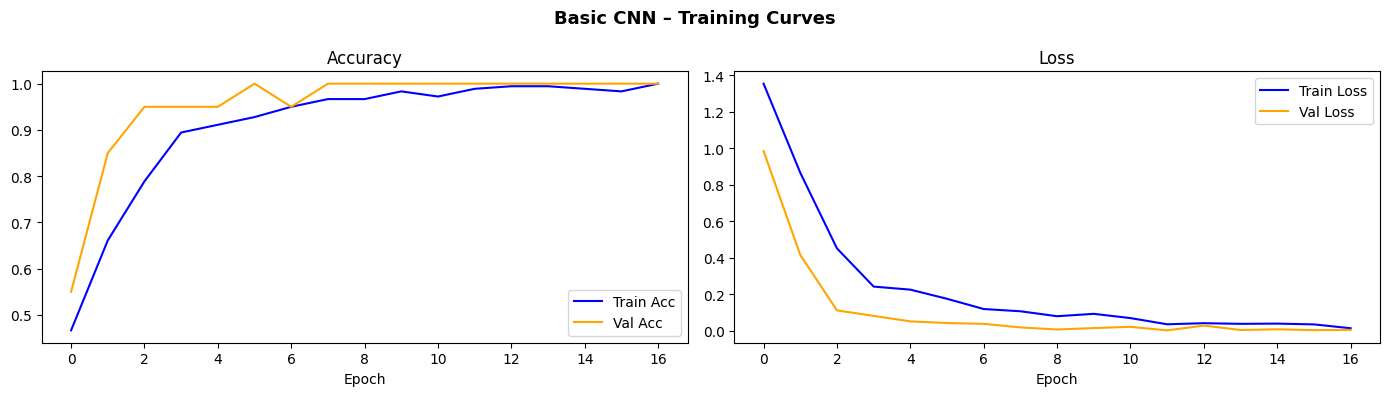

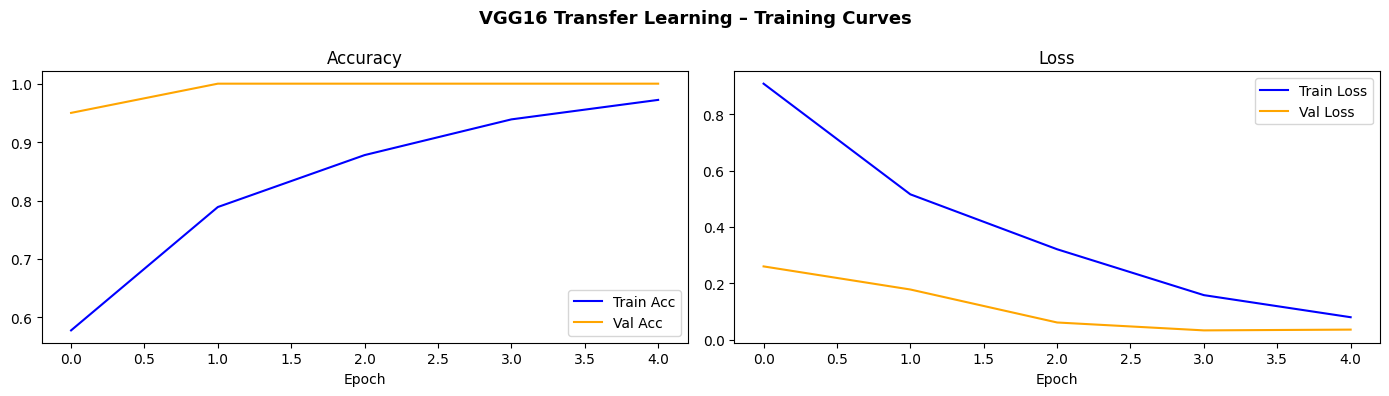

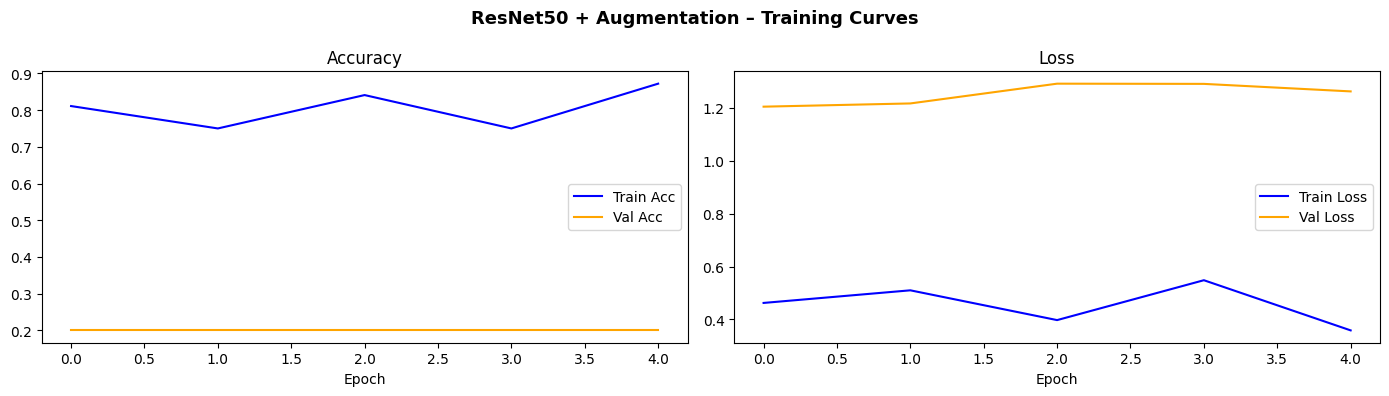

In [ ]:
# ─── Helper: plot training curves ───
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{model_name} – Training Curves', fontsize=13, fontweight='bold')

    ax1.plot(history.history['accuracy'],    label='Train Acc',  color='blue')
    ax1.plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

    ax2.plot(history.history['loss'],    label='Train Loss', color='blue')
    ax2.plot(history.history['val_loss'], label='Val Loss',  color='orange')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend()

    plt.tight_layout(); plt.show()

plot_history(history_cnn,    'Basic CNN')
plot_history(history_vgg,    'VGG16 Transfer Learning')
plot_history(history_resnet, 'ResNet50 + Augmentation')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

        Basic CNN
Test Loss      : 0.4351
Test Accuracy  : 0.9020 (90.20%)


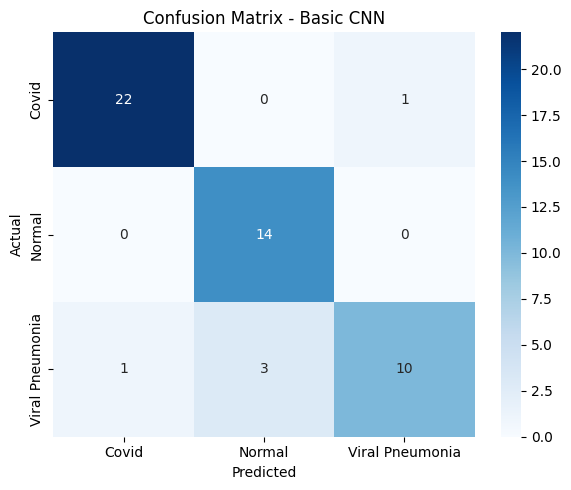


Classification Report:

                 precision    recall  f1-score   support

          Covid       0.96      0.96      0.96        23
         Normal       0.82      1.00      0.90        14
Viral Pneumonia       0.91      0.71      0.80        14

       accuracy                           0.90        51
      macro avg       0.90      0.89      0.89        51
   weighted avg       0.91      0.90      0.90        51

ROC-AUC Score (Macro OvR): 0.9736
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step

        VGG16 Transfer Learning
Test Loss      : 0.4389
Test Accuracy  : 0.8039 (80.39%)


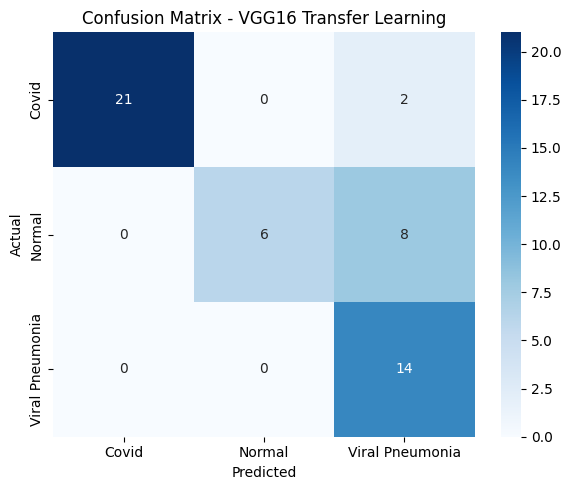


Classification Report:

                 precision    recall  f1-score   support

          Covid       1.00      0.91      0.95        23
         Normal       1.00      0.43      0.60        14
Viral Pneumonia       0.58      1.00      0.74        14

       accuracy                           0.80        51
      macro avg       0.86      0.78      0.76        51
   weighted avg       0.89      0.80      0.80        51

ROC-AUC Score (Macro OvR): 0.9929


1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/stepWARNING:tensorflow:6 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001C0B7A9C4A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step

        ResNet50 + Data Augmentation
Test Loss      : 1.1606
Test Accuracy  : 0.2745 (27.45%)


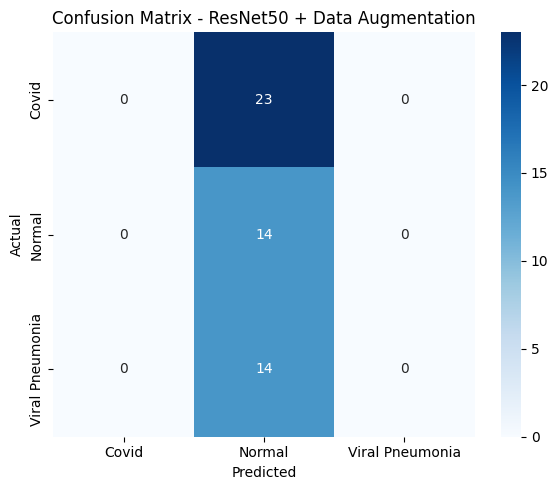


Classification Report:

                 precision    recall  f1-score   support

          Covid       0.00      0.00      0.00        23
         Normal       0.27      1.00      0.43        14
Viral Pneumonia       0.00      0.00      0.00        14

       accuracy                           0.27        51
      macro avg       0.09      0.33      0.14        51
   weighted avg       0.08      0.27      0.12        51

ROC-AUC Score (Macro OvR): 0.8974

FINAL MODEL COMPARISON
Basic CNN                     : 0.9020
VGG16 Transfer Learning       : 0.8039
ResNet50 + Augmentation       : 0.2745

Best Performing Model: Basic CNN


c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# ─────────────────────────────────────────────────────────
# REQUIRED IMPORTS
# ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# ─────────────────────────────────────────────────────────
# HELPER FUNCTION: FULL MODEL EVALUATION
# ─────────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_test, model_name):

    # Predict probabilities
    y_pred_prob = model.predict(X_test)

    # Convert probabilities to class labels
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Convert one-hot encoded labels to integers
    y_true = np.argmax(y_test, axis=1)

    # Evaluate model
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print("\n" + "="*55)
    print(f"        {model_name}")
    print("="*55)

    print(f"Test Loss      : {loss:.4f}")
    print(f"Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)")

    # ─────────────────────────────────────────────────────
    # CONFUSION MATRIX
    # ─────────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

    # ─────────────────────────────────────────────────────
    # CLASSIFICATION REPORT
    # ─────────────────────────────────────────────────────
    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=le.classes_
        )
    )

    # ─────────────────────────────────────────────────────
    # ROC-AUC SCORE
    # ─────────────────────────────────────────────────────
    try:
        roc = roc_auc_score(
            y_test,
            y_pred_prob,
            multi_class='ovr',
            average='macro'
        )

        print(f"ROC-AUC Score (Macro OvR): {roc:.4f}")

    except Exception as e:
        print("ROC-AUC could not be calculated.")
        print("Reason:", e)

    return acc, y_pred_prob

# ─────────────────────────────────────────────────────────
# EVALUATE ALL MODELS
# ─────────────────────────────────────────────────────────

acc_cnn, _ = evaluate_model(
    model_cnn,
    X_test,
    y_test,
    'Basic CNN'
)

acc_vgg, _ = evaluate_model(
    model_vgg,
    X_test,
    y_test,
    'VGG16 Transfer Learning'
)

acc_resnet, _ = evaluate_model(
    model_resnet,
    X_test,
    y_test,
    'ResNet50 + Data Augmentation'
)

# ─────────────────────────────────────────────────────────
# FINAL ACCURACY COMPARISON
# ─────────────────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL MODEL COMPARISON")
print("="*55)

print(f"Basic CNN                     : {acc_cnn:.4f}")
print(f"VGG16 Transfer Learning       : {acc_vgg:.4f}")
print(f"ResNet50 + Augmentation       : {acc_resnet:.4f}")

# Best model selection
best_acc = max(acc_cnn, acc_vgg, acc_resnet)

if best_acc == acc_cnn:
    best_model = "Basic CNN"

elif best_acc == acc_vgg:
    best_model = "VGG16 Transfer Learning"

else:
    best_model = "ResNet50 + Augmentation"

print(f"\nBest Performing Model: {best_model}")

## <span style='color: indigo'>Task 6: Handle Class Imbalance

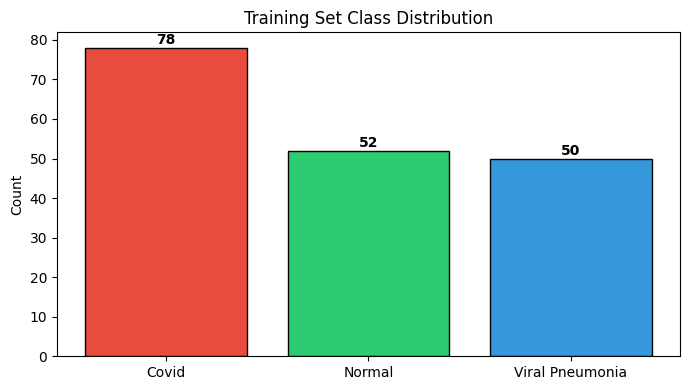

In [ ]:
# ─── Analyze class imbalance visually ───
y_train_int = np.argmax(y_train, axis=1)
unique_tr, counts_tr = np.unique(y_train_int, return_counts=True)

plt.figure(figsize=(7,4))
plt.bar(le.classes_, counts_tr, color=['#E74C3C','#2ECC71','#3498DB'], edgecolor='black')
plt.title('Training Set Class Distribution')
plt.ylabel('Count')
for i, (cls_name, cnt) in enumerate(zip(le.classes_, counts_tr)):
    plt.text(i, cnt+1, str(cnt), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─── Apply class weights in model.fit() ───
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:")
for cls, w in zip(le.classes_, class_weights_arr):
    print(f"  {cls}: {w:.3f}")

# Retrain best model (ResNet50) with class weights
model_balanced = build_resnet50_transfer()
model_balanced.compile(optimizer=keras.optimizers.Adam(1e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

history_balanced = model_balanced.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_val, y_val),
    epochs=20,
    steps_per_epoch=len(X_train)//16,
    class_weight=class_weight_dict,
    callbacks=callbacks_basic,
    verbose=1
)
print("Balanced ResNet50 training complete!")

Class weights:
  Covid: 0.769
  Normal: 1.154
  Viral Pneumonia: 1.200
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 366ms/step - accuracy: 0.6818 - loss: 0.9644 - val_accuracy: 0.5000 - val_loss: 1.0361 - learning_rate: 1.0000e-04
Epoch 2/20
 1/11 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5000 - loss: 0.8088

c:\Users\USER\myenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.8088 - val_accuracy: 0.5000 - val_loss: 1.0363 - learning_rate: 1.0000e-04
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6931 - loss: 0.7541
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.7012 - loss: 0.6655 - val_accuracy: 0.5000 - val_loss: 1.0313 - learning_rate: 1.0000e-04
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8125 - loss: 0.4886 - val_accuracy: 0.5000 - val_loss: 1.0313 - learning_rate: 5.0000e-05
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.7744 - loss: 0.5967 - val_accuracy: 0.5000 - val_loss: 1.0303 - learning_rate: 5.0000e-05
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Balanced ResNet50 training complete!


## <span style='color: indigo'>Task 7: Model Tuning

In [ ]:
# ─── Install Keras Tuner ───
!pip install keras-tuner -q
import keras_tuner as kt

In [ ]:
# ─── Keras Tuner Code ───

import keras_tuner as kt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Build model
def build_model(hp):

    model = models.Sequential([
        layers.Conv2D(
            hp.Choice('filters', [32, 64]),
            (3,3),
            activation='relu',
            input_shape=(128,128,3)
        ),

        layers.MaxPooling2D(2,2),

        layers.Flatten(),

        layers.Dense(
            hp.Choice('dense', [128, 256]),
            activation='relu'
        ),

        layers.Dropout(
            hp.Float('dropout', 0.2, 0.5, step=0.1)
        ),

        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,          # Reduced for faster run
    overwrite=True,
    directory='temp_dir'
)

# Search
tuner.search(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,              # Reduced epochs
    batch_size=32,
    callbacks=[EarlyStopping(patience=2)]
)

# Best model
best_model = tuner.get_best_models(1)[0]

# Evaluate
loss, acc = best_model.evaluate(X_test, y_test)

print(f"\nBest Accuracy: {acc:.4f}")

Trial 3 Complete [00h 00m 14s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 51s


c:\Users\USER\myenv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9020 - loss: 0.2934 

Best Accuracy: 0.9020


## <span style='color: indigo'>Task 8: Model Comparison Table

In [ ]:
# ─── Build comparison table ───
def get_metrics(model, history, X_tr, y_tr, X_te, y_te):
    tr_acc  = max(history.history['accuracy'])
    te_loss, te_acc = model.evaluate(X_te, y_te, verbose=0)
    y_pred  = np.argmax(model.predict(X_te), axis=1)
    y_true  = np.argmax(y_te, axis=1)
    f1 = classification_report(y_true, y_pred, output_dict=True)['macro avg']['f1-score']
    overfit = 'Y' if (tr_acc - te_acc) > 0.10 else 'N'
    return round(tr_acc,4), round(te_acc,4), round(f1,4), overfit

rows = [
    ['CNN Basic',   *get_metrics(model_cnn,    history_cnn,    X_train, y_train, X_test, y_test)],
    ['ResNet50',    *get_metrics(model_resnet,  history_resnet, X_train, y_train, X_test, y_test)],
    ['VGG16',       *get_metrics(model_vgg,     history_vgg,    X_train, y_train, X_test, y_test)],
    ['Best (Balanced ResNet50)', *get_metrics(model_balanced, history_balanced, X_train, y_train, X_test, y_test)],
]

df_compare = pd.DataFrame(rows, columns=['Model','Train Acc','Test Acc','F1 Score','Overfitting'])
print(df_compare.to_string(index=False))

# Highlight best
best_row = df_compare.loc[df_compare['Test Acc'].idxmax()]
print(f"\n✅ Best Model: {best_row['Model']} | Test Acc: {best_row['Test Acc']} | F1: {best_row['F1 Score']}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step


c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 380ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
                   Model  Train Acc  Test Acc  F1 Score Overfitting
               CNN Basic     1.0000    0.9020    0.8866           N
                ResNet50     0.8720    0.2745    0.1436           Y
                   VGG16     0.9722    0.8039    0.7638           Y
Best (Balanced ResNet50)     0.8125    0.4510    0.2072           Y

✅ Best Model: CNN Basic | Test Acc: 0.902 | F1: 0.8866


c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## <span style='color: indigo'> Task 9: Save the Best Model (for Streamlit App)

In [ ]:
# ─── Save best model as Manna.pkl ───
# Identify best model by test accuracy
# ─── IMPORT ───
import pickle

# ─── SAVE BEST MODEL ───

best_models = {
    'CNN Basic': model_cnn,
    'ResNet50': model_resnet,
    'VGG16': model_vgg,
    'Balanced ResNet50': model_balanced
}

# Best model name from dataframe
best_name = df_compare.loc[
    df_compare['Test Acc'].idxmax(),
    'Model'
]

# Name mapping
name_map = {
    'CNN Basic': 'CNN Basic',
    'ResNet50': 'ResNet50',
    'VGG16': 'VGG16',
    'Best (Balanced ResNet50)': 'Balanced ResNet50'
}

# Select best model
best_model_to_save = best_models[name_map[best_name]]

# Save information
model_info = {
    'model': best_model_to_save,
    'label_encoder': le,
    'classes': list(le.classes_),
    'img_size': 128,
    'model_name': best_name
}

# Save as PKL
with open('Manna.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f"✅ Saved {best_name} as Manna.pkl")

# Save as Keras model
best_model_to_save.save('best_model.keras')

print("✅ Saved as best_model.keras")

✅ Saved CNN Basic as Manna.pkl
✅ Saved as best_model.keras


## <span style='color: indigo'> Please find my app.py file code-

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Load model
model = tf.keras.models.load_model("best_model.keras")

classes = ['COVID', 'NORMAL', 'PNEUMONIA']

st.title("COVID-19 Detection from Chest X-rays")

file = st.file_uploader(
    "Upload Chest X-ray",
    type=["jpg", "png", "jpeg"]
)

if file:

    img = Image.open(file).convert("RGB")
    st.image(img, use_container_width=True)

    # Preprocess
    img = img.resize((128,128))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    pred = model.predict(img)

    result = classes[np.argmax(pred)]
    confidence = np.max(pred) * 100

    st.success(f"Prediction: {result}")
    st.write(f"Confidence: {confidence:.2f}%")


## <span style='color: indigo'> Please find my github refererance link-https://github.com/Madhusudan-Manna/COVID-19-Detection-from-Chest-X-rays-using-CNN-Deep-Learning-Streamlit-Web-App-Madhusudan-Manna1

## <span style='color: indigo'>Please find my streamlit local host model link- http://localhost:8501/

## <span style='color: indigo'>Please find my streamlit deployment Mini Project: COVID-19 Detection from Chest X-rays using CNN-


# <span style='color: indigo'> Thank You !